In [131]:
import pandas as pd
import obspy
import numpy as np
import matplotlib.pyplot as plt
from obspy import UTCDateTime
import os

import random
import json
Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.

5.7


In [132]:
from new_functions import *

Earthquake at 2023-06-16T16:38:28.069000Z with magnitude 4.8


Processing stations of BGR: 100%|██████████| 191/191 [00:08<00:00, 21.59it/s]


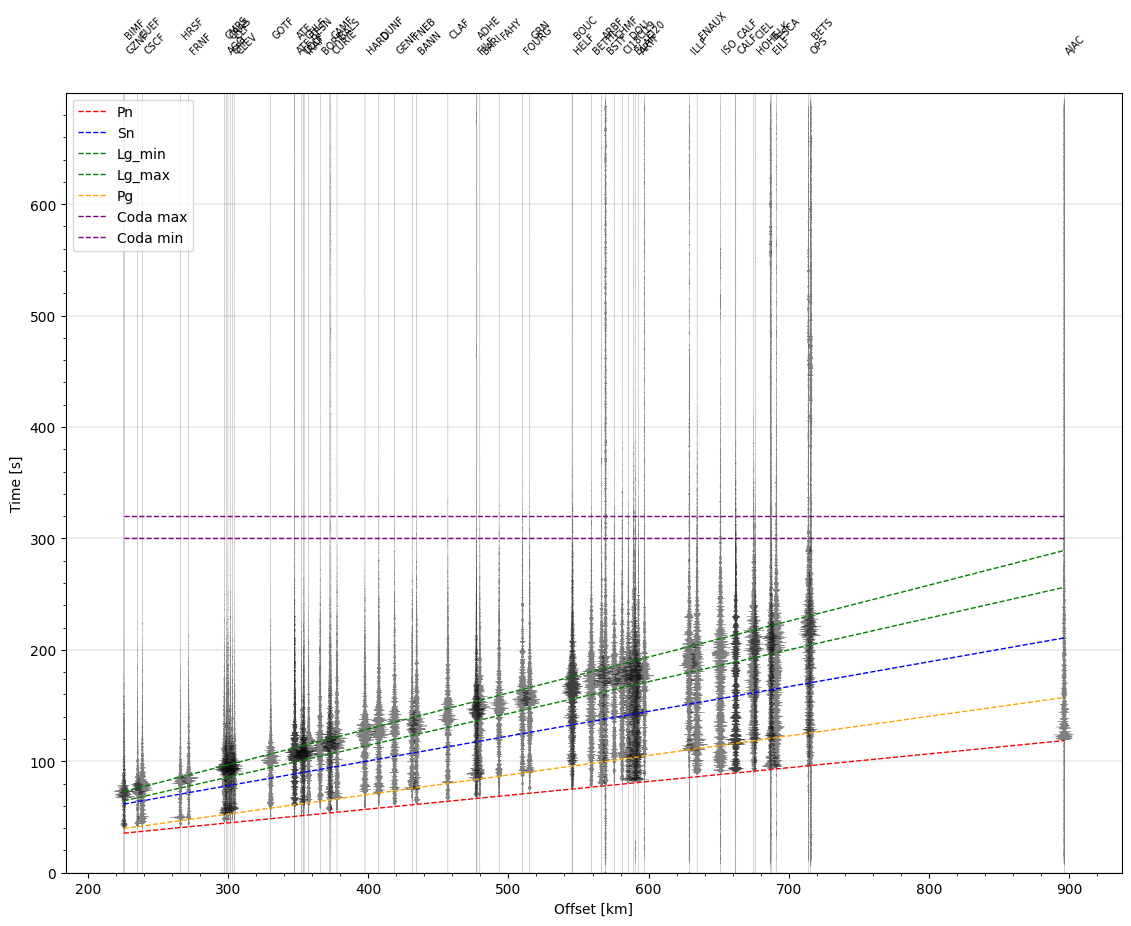

In [133]:
import warnings
warnings.filterwarnings("ignore")
datacenters =['RESIF','ODC','ETH','INGV','GEOFON', 'IRIS', 'ICGC','BGR']
directory='/home/schreinl/Stage/Data/'
distmin=1.9
distmax=10.
catalogue_4_5 = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')

#catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/eq_4_france.csv')
#catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)
start = UTCDateTime(catalogue_4_5['time'][0])
end = start + 700
eq_lon = float(catalogue_4_5['longitude'][0])
eq_lat = float(catalogue_4_5['latitude'][0])
st_all, stations_all, plot = big_downloader2(datacenters, start, end, eq_lon, eq_lat, distmin, distmax, directory, plot=False)
time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")



st_plot_filt_all=st_all.copy()
fmin=3
fmax=6
st_plot_filt_all.filter("bandpass", freqmin=fmin, freqmax=fmax)


plot, st_Lg0 = plot_record_section(st_plot_filt_all[0:60], stations_all[0:60], eq_lat, 
eq_lon, start, tracehodo=True, v_Lg_min=vLg_min, v_Lg_max=vLg_max, 
v_Pg=vPg)


In [41]:
print(type(time_string))

<class 'str'>


In [134]:
import obspy
from scipy.fftpack import hilbert
from scipy.signal import savgol_filter

import numpy as np
#from obspy.signal.filter import envelope
from scipy.signal import resample


def envelope_calculator(data):
    hilb = hilbert(data)
    data = (data ** 2 + hilb ** 2) ** 0.5
    return data


st_envelope = obspy.Stream()
smallest = 7000
for tr in st_plot_filt_all:
    data_envelope = envelope_calculator(tr.data)
    npts = tr.stats.npts
    if npts >= smallest:
        samprate = tr.stats.sampling_rate
        t = np.arange(0, npts / samprate, 1 / samprate)
        tr_envelope = obspy.Trace(data=data_envelope, header=tr.stats)
        #data_resampled = resample(tr_envelope.data, 10000)
        #tr_resampled = obspy.Trace(data=data_resampled, header=tr.stats)
        st_envelope.append(tr_envelope)

71
161
471


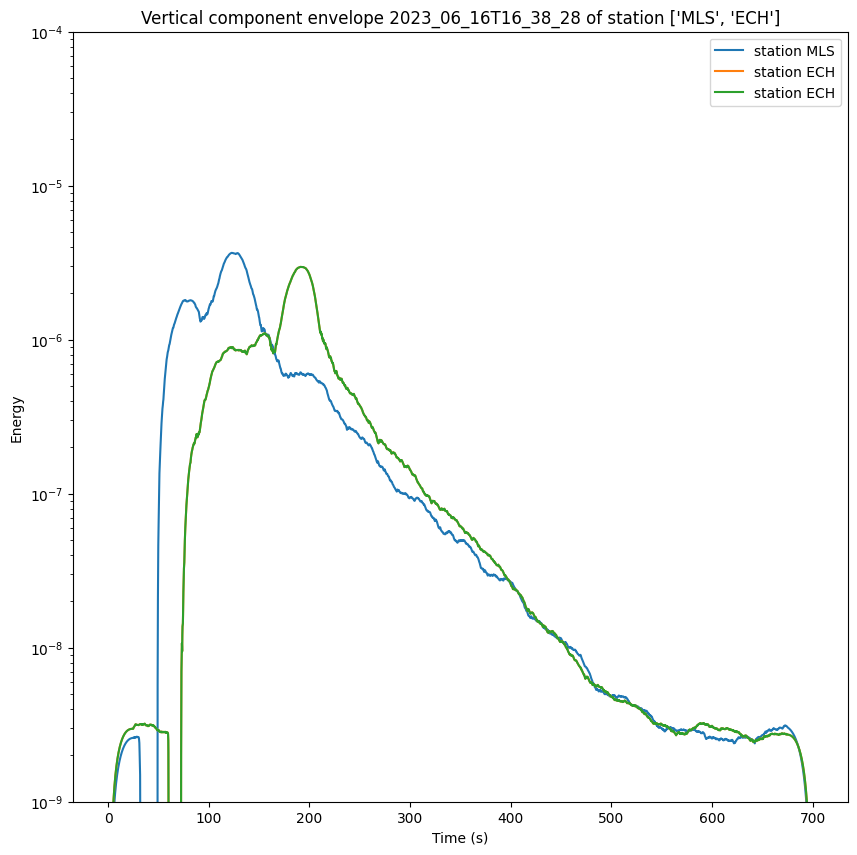

In [135]:
station = ["MLS","ECH"]
plt.figure(figsize=(10,10))
for i,tr in enumerate(st_envelope):
    if tr.stats.station == station[0] or tr.stats.station == station[1]:
        idx_reference = i
        print(i)
        npts = len(tr.data)
        samprate = tr.stats.sampling_rate #10000/700 
        t = np.arange(0, npts / samprate, 1 / samprate)

        #use a stable window length in s, while the window lenght in samples is dependant on the sample rate
        
        window_length = 50*samprate #min(2000, npts)
        if window_length % 2 == 0:
            window_length -= 1
        yhat = savgol_filter(tr.data, int(window_length), 3) 
        t = t[:len(yhat)]
        plt.title(f"Vertical component envelope {time_string} of station {station}")
        plt.ylabel("Energy")
        plt.xlabel("Time (s)")
        #plt.semilogy(t,st_envelope[i])
        plt.semilogy(t,yhat,label=f'station {tr.stats.station}')
        plt.ylim([1e-9,1e-4])
        #plt.xlim([100,350])
        plt.legend()
plt.show()

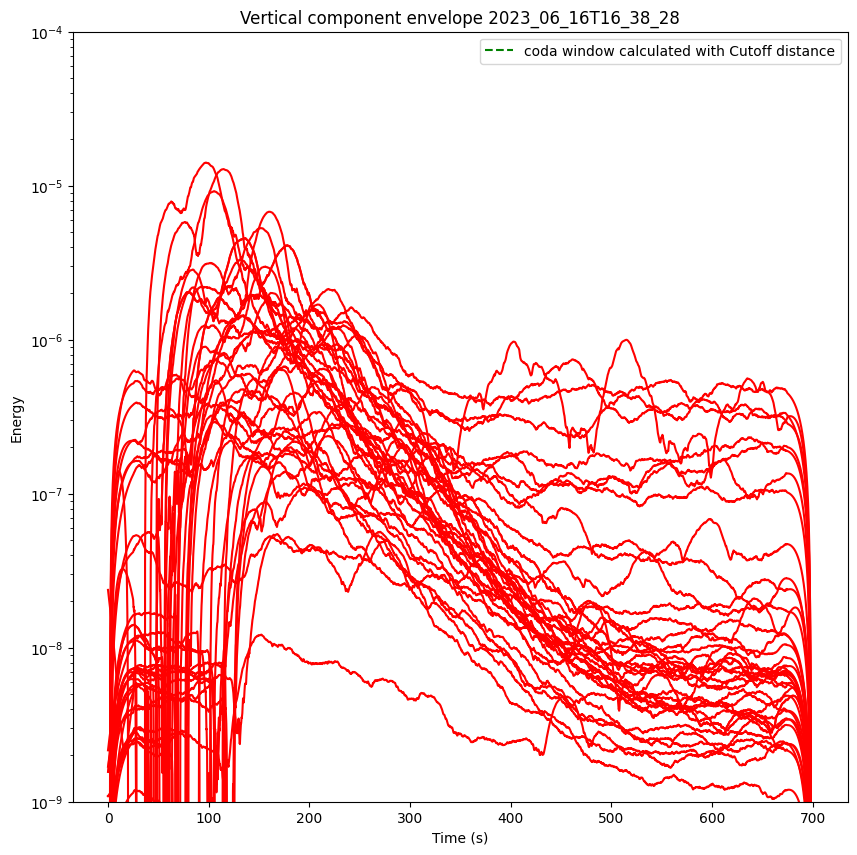

In [136]:
from scipy.signal import savgol_filter
from random import randint
def smooth_plot_envelope(time_string, n_traces,st_envelope, method='Cutoff distance',tmincoda_dist=None, tmaxcoda_dist=None,tmincoda_S = None, tmaxcoda_S= None,plotshow=False, savefig=True):
    testing = [(randint(1, len(st_plot_filt_all))) for i in range(n_traces)]

    plt.figure(figsize=(10,10))
    for i in testing:
        if i < len(st_envelope):
            npts = len(st_envelope[i].data)
            samprate = st_envelope[i].stats.sampling_rate #10000/700 
            t = np.arange(0, npts / samprate, 1 / samprate)

            #use a stable window length in s, while the window lenght in samples is dependant on the sample rate
            
            window_length = min(50*samprate, npts) # Ensure window_length is not greater than npts
            if window_length % 2 == 0:
                window_length -= 1
            yhat = savgol_filter(st_envelope[i].data, int(window_length), 3) 
            t = t[:len(yhat)]

            #plt.semilogy(t,st_envelope[i])
            plt.semilogy(t,yhat, color='red')
            plt.ylim([1e-9,1e-4])
            plt.title(f"Vertical component envelope {time_string}")
            plt.ylabel("Energy")
            plt.xlabel("Time (s)")
            #plt.xlim([100,350])
    plt.vlines(tmaxcoda_dist,ymax=1e-4,ymin=1e-9, label=f'coda window calculated with {method}',colors='g',linestyles='--')
    plt.vlines(tmincoda_dist,ymax=1e-4,ymin=1e-9,colors='g',linestyles='--')
    if tmincoda_S is not None and tmaxcoda_S is not None:
        plt.vlines(tmaxcoda_S,ymax=1e-4,ymin=1e-9, label='coda window calculated with S-wave',colors='b',linestyles='--')
        plt.vlines(tmincoda_S,ymax=1e-4,ymin=1e-9,colors='b',linestyles='--')
    #plt.vlines(350,ymax=1e-4,ymin=1e-9, label='coda window similar to Galina&Shapiro 2024',colors='b',linestyles='--')
    #plt.vlines(470,ymax=1e-4,ymin=1e-9,colors='b',linestyles='--')
    plt.legend()
    if savefig:
        mag_dir = '/home/schreinl/Stage/Data/Metadata/'
        with open(f"{mag_dir}{time_string}.txt", "r") as meta:
            for line in meta:
                if line.startswith("Magnitude:"):
                    magnitude = float(line.split(":")[1].strip())
        plt.savefig(f'/home/schreinl/Stage/Figures/SiteEffect/multiple_envelopes_{time_string}_{magnitude}_{method}_filtered.png', format='png')
    if plotshow:
        plt.show()
    
    return  
tset = smooth_plot_envelope(time_string, 50,st_envelope)

In [130]:
snr_threshold = 2
eq_start = start
stationref = "ECH"

filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_cutoff, filtered_st, stations_with_amps, amp_plot = SNR_all(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min, vPg_max, tminCoda, tmaxCoda,
         Dtmin_Noise, Dtmax_Noise,eq_start,eq_lat,eq_lon,snr_threshold=snr_threshold,plot_SNR=False,plot_amps=True, wavecode="Lg_Coda",dB=True,codawindow="cutoff",factor=1.1)


filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_S, filtered_st, stations_with_amps, amp_plot = SNR_all(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min, vPg_max, tminCoda, tmaxCoda,
         Dtmin_Noise, Dtmax_Noise,eq_start,eq_lat,eq_lon,snr_threshold=snr_threshold,plot_SNR=False,plot_amps=True, wavecode="Lg_Coda",dB=True,codawindow="S_phase", factor=2)

#print(filtered_stations_with_SNR)
for i,tr in enumerate(st_envelope):
    if tr.stats.station == stationref:
        idx_reference = i


filtered_station_names = set(row[1] for row in filtered_stations_with_SNR) 
filtered_smooth_stream = obspy.Stream()
filtered_stream = obspy.Stream()

for trace in st_envelope:
    if trace.stats.station in filtered_station_names:
        filtered_stream.append(trace)




for i,tr in enumerate(filtered_stream):
    if tr.stats.station == stationref:
        idx_reference = i


plot_filtered_smoothed = smooth_plot_envelope(time_string, 50,filtered_stream,method="cutoff distance",
                    tmincoda_dist=tcoda_cutoff, tmaxcoda_dist=tcoda_cutoff+100, tmincoda_S=tcoda_S, tmaxcoda_S=tcoda_S+100, savefig=False)

calculating SNR for Pn  phase
calculating SNR for Pg  phase
calculating SNR for Sn  phase
calculating SNR for Lg  phase
No valid SNR values above 2.


UnboundLocalError: local variable 'percentile_distance' referenced before assignment

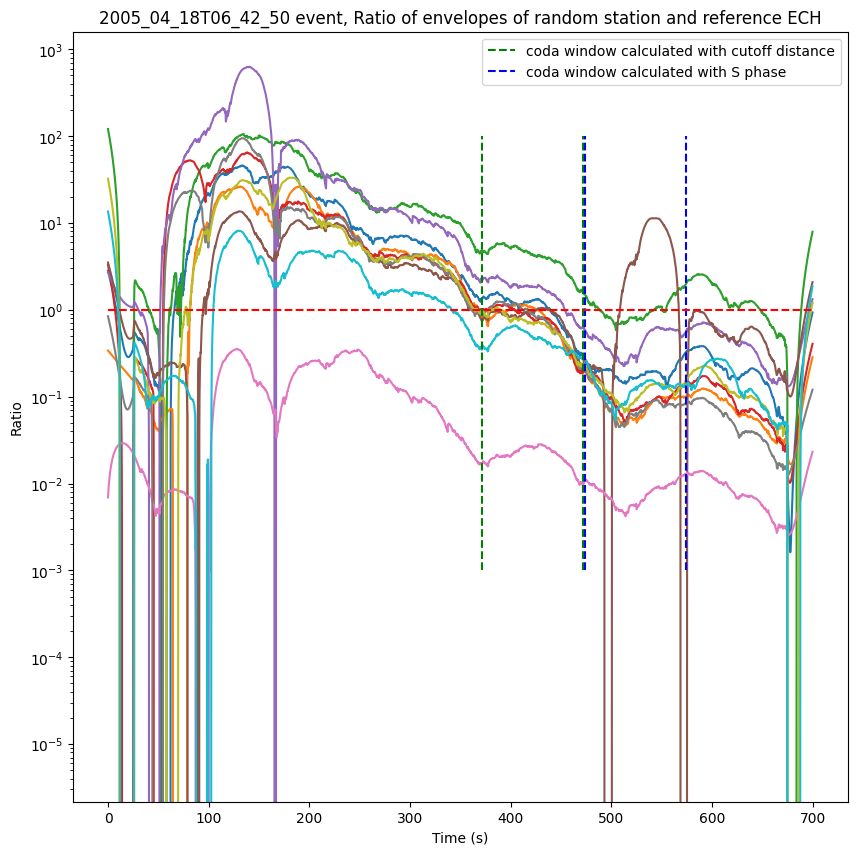

In [129]:
plt.figure(figsize=(10,10))
n_traces = 10
testing = [(randint(1, len(filtered_stream))) for i in range(n_traces)]
for trace_idx in testing:
    trace = filtered_stream[trace_idx]
    plt.semilogy(np.arange(0,700,0.01),savgol_filter(np.divide(resample(trace.data,70000),resample(st_envelope[idx_reference].data,70000)),5000,3))
plt.title(f"{time_string} event, Ratio of envelopes of random station and reference ECH")
plt.vlines(tcoda_cutoff,ymax=1e2,ymin=1e-3, label='coda window calculated with cutoff distance',colors='g',linestyles='--')
plt.vlines(tcoda_cutoff+100,ymax=1e2,ymin=1e-3,colors='g',linestyles='--')
plt.vlines(tcoda_S,ymax=1e2,ymin=1e-3, label='coda window calculated with S phase',colors='b',linestyles='--')
plt.vlines(tcoda_S+100,ymax=1e2,ymin=1e-3,colors='b',linestyles='--')
#plt.vlines(tmincoda_dist,ymax=1e2,ymin=1e-3, label='coda window calculated with min Lg velocity',colors='r',linestyles='--')
#plt.vlines(tmincoda_dist+100,ymax=1e2,ymin=1e-3,colors='r',linestyles='--')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Ratio')
plt.hlines(1,xmin=0,xmax=700, linestyles="--",colors='r')

In [193]:
eq_list = pd.read_csv('/home/schreinl/Stage/Data/trial.csv')
eq_list = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')

amplitudes_dict = {}

for i in range(len(eq_list)):
    start = UTCDateTime(eq_list["time"][i])
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    magnitude = eq_list["mag"][i]
    
    try:
        with open(f"/home/schreinl/Stage/Data/{time_string}/{time_string}_envelope_amps_cutoff_fac_1.1_dict.txt", "r") as file:
            amp_dict = json.load(file)
        for station, data in amp_dict.items():
            if station not in amplitudes_dict:
                amplitudes_dict[station] = [None] * i 
            amplitudes_dict[station].append({
                "amplitude": data["amplitude"], 
                "time": time_string, 
                "magnitude": magnitude, 
                "snr_coda": data.get("snr_coda", None), 
                "snr_last_window": data.get("snr_coda_end", None)
            })
        
        for station in amplitudes_dict:
            if station not in amp_dict:
                amplitudes_dict[station].append(None)
    except FileNotFoundError:
        for station in amplitudes_dict:
            amplitudes_dict[station].append(None)

print(amplitudes_dict['ECH'])


[{'amplitude': 2.5122898150014396e-09, 'time': '2023_06_16T16_38_28', 'magnitude': 4.8, 'snr_coda': 19.724606285901487, 'snr_last_window': 22.538491253727877}, None, None, {'amplitude': 2.837883904419483e-10, 'time': '2022_03_12T17_03_22', 'magnitude': 4.5, 'snr_coda': 2.4753971969320863, 'snr_last_window': 3.515990516205089}, None, None, {'amplitude': 1.4283188707700826e-10, 'time': '2020_12_29T14_36_56', 'magnitude': 4.6, 'snr_coda': 1.0373952644973758, 'snr_last_window': 1.4094439760837307}, {'amplitude': 1.8684307342341952e-10, 'time': '2020_09_30T22_02_31', 'magnitude': 4.6, 'snr_coda': 1.7347366533171291, 'snr_last_window': 2.198595194869849}, None, None, {'amplitude': 1.5463101385539684e-09, 'time': '2019_11_11T10_52_46', 'magnitude': 4.8, 'snr_coda': 11.557650428101192, 'snr_last_window': 14.717728687777905}, None, {'amplitude': 2.434641514450888e-10, 'time': '2019_03_20T09_56_40', 'magnitude': 4.5, 'snr_coda': 1.2678900361085135, 'snr_last_window': 1.5813785695089289}, {'ampli

In [197]:
import folium
import glob
import os

# Calculate the average latitude and longitude for the map center
avg_lat = np.mean([station[2] for station in stations_all])
avg_lon = np.mean([station[3] for station in stations_all])
map_center = [avg_lat, avg_lon]
event_map = folium.Map(location=map_center, zoom_start=5)

# Add station markers to the map
for station in stations_all:
    lat = station[2]
    lon = station[3]
    name = station[1]
    folium.Marker(
        location=[lat, lon],
        tooltip=name,
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(event_map)

# Find and plot stations from each event directory
#event_directories = glob.glob('/home/schreinl/Stage/Data/*/')
#for event_dir in event_directories:
#    snr_files = glob.glob(os.path.join(event_dir, '*_unfiltered_stations_SNR.txt'))
#   for snr_file in snr_files:
#       with open(snr_file, 'r') as file:
##            lines = file.readlines()
 #           for line in lines:
 #               parts = line.strip().split(',')
 #               if len(parts) > 3:
 #                   lat = float(parts[2].strip('"'))
 #                   lon = float(parts[3].strip('"'))
 #                   name = parts[1].strip('"')
 #                   folium.Marker(
 #                       location=[lat, lon],
 #                       tooltip=name,
 #                       icon=folium.Icon(color='green', icon='info-sign')
 #                   ).add_to(event_map)

event_map

### Find fitting Reference station

In [123]:
from obspy.clients.fdsn import Client
import folium

client = Client("RESIF")
network = "*"
stations = ["SSB", "ECH", "CHIF", "BALS", "MLS", "CLF", "OGDI", "EUCT"]

inventory = client.get_stations(network=network, station=",".join(stations), level="station")

origin = [47, 9]
zoom = 5

carte = folium.Map(location=origin, zoom_start=zoom)

for network in inventory:
    for station in network:
        lat = station.latitude
        lon = station.longitude
        name = station.code
        infos = f"{name} ({lat}, {lon})"
        folium.Marker(
            location=[lat, lon],
            tooltip=infos,
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(carte)

carte


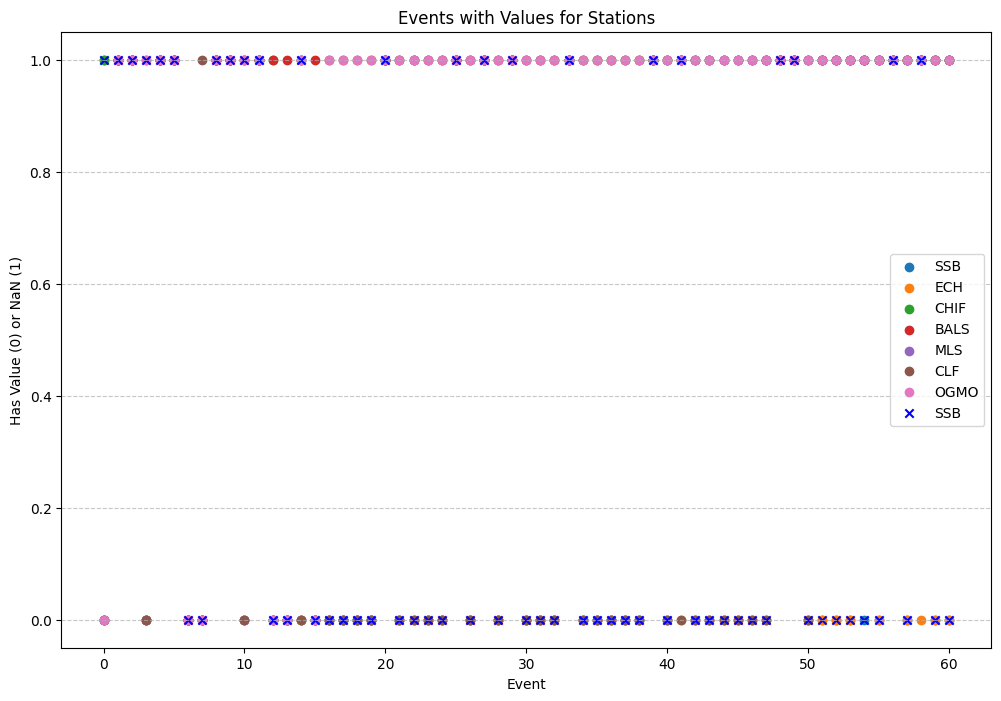

In [124]:
fallback_stations = ["SSB", "ECH", "CHIF", "BALS", "MLS", "CLF", "OGMO"]
amplitude_ratios = {}

total_stations = len(amplitudes_dict.keys())
stations_with_no_valid_ratio = 0

plt.figure(figsize=(12, 8))

for fallback_station in fallback_stations:
    ech_values = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[fallback_station]], dtype=np.float64)
    ssb_values = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

    ech_values = np.where(ech_values == None, np.nan, ech_values)
    ssb_values = np.where(ssb_values == None, np.nan, ssb_values)

    plt.scatter(events, np.isnan(ech_values), label=f'{fallback_station}', marker='o')

plt.scatter(events, np.isnan(ssb_values), label='SSB', marker='x', color='b')

plt.xlabel("Event")
plt.ylabel("Has Value (0) or NaN (1)")
plt.title("Events with Values for Stations")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


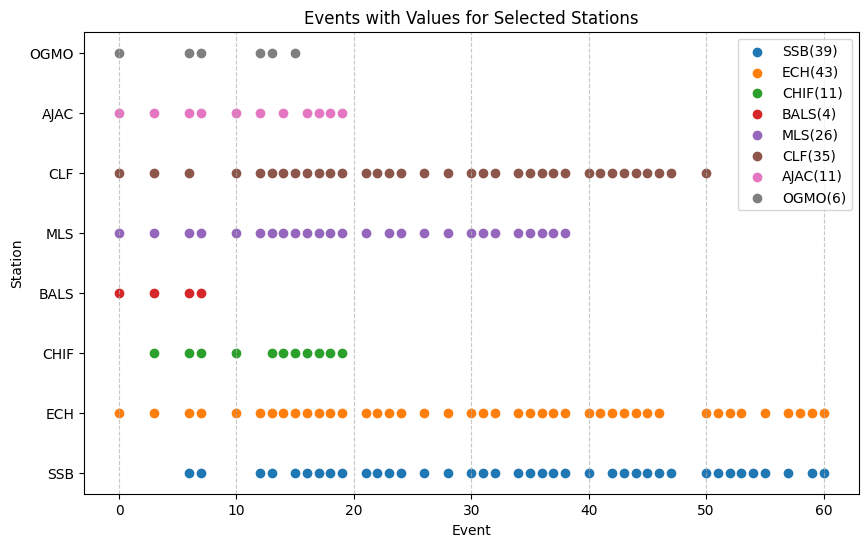

In [125]:
stations_to_plot = ["SSB", "ECH", "CHIF", "BALS", "MLS", "CLF", 'AJAC', "OGMO"]
events = range(len(amplitudes_dict[station2]))

plt.figure(figsize=(10, 6))

for i, station in enumerate(stations_to_plot):
    values = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    values = np.where(values == None, np.nan, values)
    event_indices = [event for event, value in enumerate(values) if not np.isnan(value)]
    count = len(event_indices)
    plt.scatter(event_indices, [i] * len(event_indices), label=f"{station}({count})", marker='o')

plt.xlabel("Event")
plt.ylabel("Station")
plt.yticks(range(len(stations_to_plot)), stations_to_plot)
plt.title("Events with Values for Selected Stations")
plt.legend(loc='upper right')
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [53]:
import random

station_tests = random.sample(list(amplitudes_dict.keys()), 25)
'''
amplitudes_dict_sample = {station: [] for station in station_tests}

for i in range(len(eq_list)):
    start = UTCDateTime(eq_list["time"][i])
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    
    try:
        with open(f"/home/schreinl/Stage/Data/{time_string}/{time_string}_envelope_amps_fac_1.5_dict.txt", "r") as file:
            amp_dict = json.load(file)

        for station in station_tests:
            if station in amp_dict:
                amplitudes_dict[station].append((time_string, amp_dict[station]["amplitude"]))
            else:
                amplitudes_dict[station].append((time_string, None))
    except FileNotFoundError:
        for station in station_tests:
            amplitudes_dict[station].append((time_string, None))

print(len(amplitudes_dict_sample))
'''

'\namplitudes_dict_sample = {station: [] for station in station_tests}\n\nfor i in range(len(eq_list)):\n    start = UTCDateTime(eq_list["time"][i])\n    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")\n    \n    try:\n        with open(f"/home/schreinl/Stage/Data/{time_string}/{time_string}_envelope_amps_fac_1.5_dict.txt", "r") as file:\n            amp_dict = json.load(file)\n\n        for station in station_tests:\n            if station in amp_dict:\n                amplitudes_dict[station].append((time_string, amp_dict[station]["amplitude"]))\n            else:\n                amplitudes_dict[station].append((time_string, None))\n    except FileNotFoundError:\n        for station in station_tests:\n            amplitudes_dict[station].append((time_string, None))\n\nprint(len(amplitudes_dict_sample))\n'

In [126]:
for station in amplitudes_dict:
    amplitudes = amplitudes_dict[station]
    recorded_count = sum(amp is not None for amp in amplitudes)
    total_events = len(amplitudes_dict["ECH"])  
    
    print(f"Station {station} recorded {recorded_count} earthquakes out of {total_events}")



Station CI18 recorded 5 earthquakes out of 61
Station CI19 recorded 5 earthquakes out of 61
Station CI20 recorded 5 earthquakes out of 61
Station BETS recorded 5 earthquakes out of 61
Station ILLK recorded 5 earthquakes out of 61
Station OPS recorded 5 earthquakes out of 61
Station ADHE recorded 1 earthquakes out of 61
Station AGO recorded 5 earthquakes out of 61
Station AJAC recorded 11 earthquakes out of 61
Station ARBF recorded 22 earthquakes out of 61
Station ARTF recorded 7 earthquakes out of 61
Station ATE recorded 29 earthquakes out of 61
Station BALS recorded 4 earthquakes out of 61
Station BANN recorded 5 earthquakes out of 61
Station BARI recorded 4 earthquakes out of 61
Station BESN recorded 3 earthquakes out of 61
Station BETHI recorded 2 earthquakes out of 61
Station BIMF recorded 3 earthquakes out of 61
Station BLAF recorded 10 earthquakes out of 61
Station BORF recorded 2 earthquakes out of 61
Station BOUC recorded 5 earthquakes out of 61
Station BSTF recorded 11 earthqu

Mean Ratio (SULZ / ECH): 2.07643
Standard Deviation: 0.67322
Median: 2.04984
Min Ratio: 1.08673
Max Ratio: 4.39779


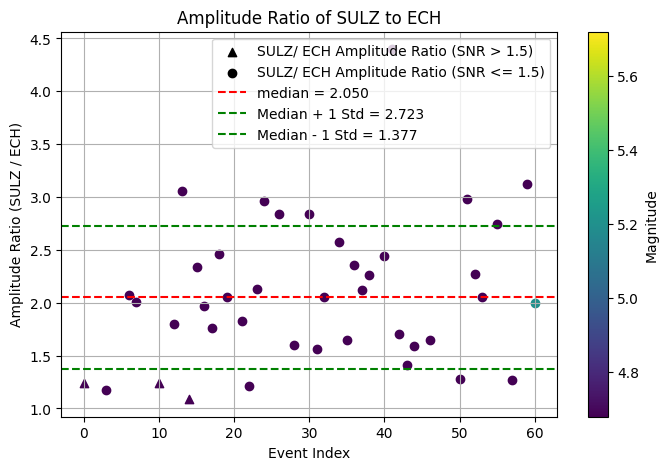

In [176]:
station1 = "SULZ"
station2 = "ECH"

denom_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station1]], dtype=np.float64)
counter_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
valid_ratios = ratio[~np.isnan(ratio)]
mean_ratio = np.nanmean(valid_ratios)
std_ratio = np.nanstd(valid_ratios)
median_ratio = np.nanmedian(valid_ratios)
min_ratio = np.nanmin(valid_ratios)
max_ratio = np.nanmax(valid_ratios)

magnitudes = np.array([entry['magnitude'] if entry is not None else None for entry in amplitudes_dict[station1]], dtype=np.float64)
magnitudes = np.where(magnitudes == None, np.nan, magnitudes)

print(f"Mean Ratio ({station1} / {station2}): {mean_ratio:.5f}")
print(f"Standard Deviation: {std_ratio:.5f}")
print(f"Median: {median_ratio:.5f}")
print(f"Min Ratio: {min_ratio:.5f}")
print(f"Max Ratio: {max_ratio:.5f}")

plt.figure(figsize=(8, 5))
plt.scatter([], [], c='k', marker="^", label=f"{station1}/ {station2} Amplitude Ratio (SNR > 1.5)")
plt.scatter([], [], c='k', marker="o", label=f"{station1}/ {station2} Amplitude Ratio (SNR <= 1.5)")

for i, (r, mag) in enumerate(zip(ratio, magnitudes)):
    if not np.isnan(r):
        snr_coda = amplitudes_dict[station1][i].get('snr_coda', None)
        if snr_coda is not None and snr_coda > 1.5:
            plt.scatter(i, r, c=mag, cmap='viridis', marker="^")
        else:
            plt.scatter(i, r, c=mag, cmap='viridis', marker="o")

plt.colorbar(label='Magnitude')
plt.axhline(median_ratio, color="r", linestyle="--", label=f"median = {median_ratio:.3f}")
plt.axhline(median_ratio + std_ratio, color="g", linestyle="--", label=f"Median + 1 Std = {median_ratio + std_ratio:.3f}")
plt.axhline(median_ratio - std_ratio, color="g", linestyle="--", label=f"Median - 1 Std = {median_ratio - std_ratio:.3f}")

plt.xlabel("Event Index")
plt.ylabel(f"Amplitude Ratio ({station1} / {station2})")
plt.title(f"Amplitude Ratio of {station1} to {station2}")
plt.legend()
plt.grid(True)
plt.show()


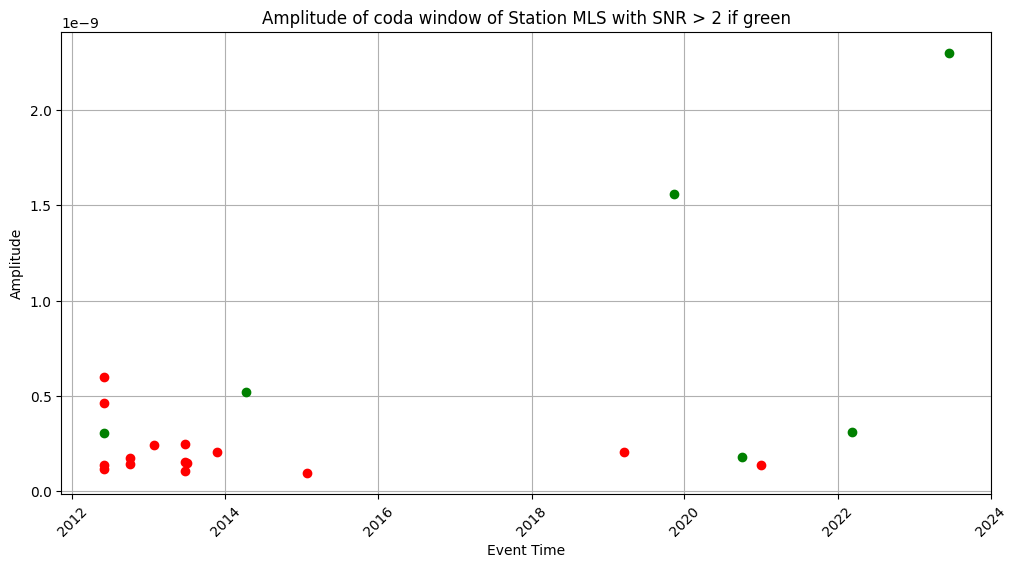

In [192]:
stationcheck = "MLS"

ech_amplitudes = [entry['amplitude'] if entry is not None else np.nan for entry in amplitudes_dict[stationcheck]]
snr_coda_values = [entry['snr_coda'] if entry is not None else np.nan for entry in amplitudes_dict[stationcheck]]
event_times = [entry['time'] if entry is not None else 'None' for entry in amplitudes_dict['ECH']]
valid_indices = [i for i, time in enumerate(event_times) if time != 'None']
valid_times = [event_times[i] for i in valid_indices]
valid_amplitudes = [ech_amplitudes[i] for i in valid_indices]
valid_snr_coda = [snr_coda_values[i] for i in valid_indices]
valid_times = [datetime.strptime(time, '%Y_%m_%dT%H_%M_%S') for time in valid_times]

plt.figure(figsize=(12, 6))
for time, amplitude, snr_coda in zip(valid_times, valid_amplitudes, valid_snr_coda):
    if snr_coda is not None:
        color = 'green' if snr_coda > 2 else 'red'
        plt.plot(time, amplitude, 'o', color=color)
#plt.text(0.5, 0.5, 'Green: SNR > 2', color='green')
#plt.text(0.5, 0.5, 'Red: SNR <= 2', color='red')
plt.xlabel('Event Time')
plt.ylabel('Amplitude')
plt.title(f'Amplitude of coda window of Station {stationcheck} with SNR > 2 if green')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

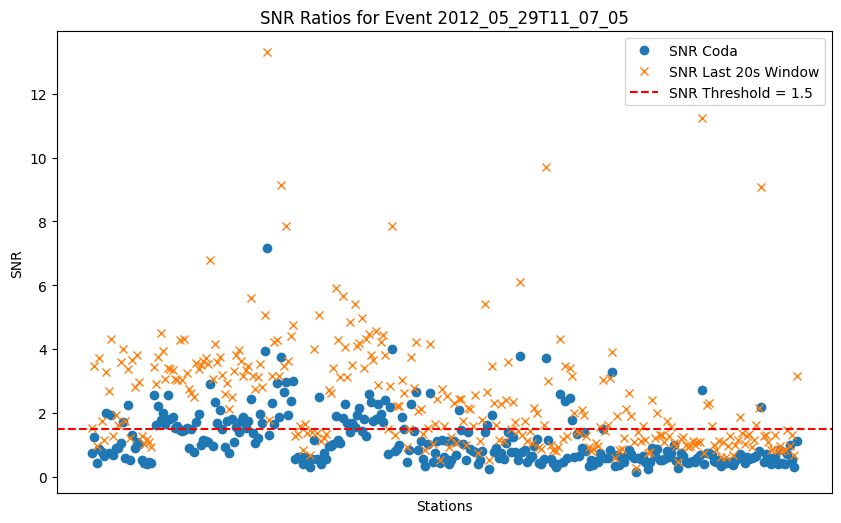

In [177]:
event_index = 26

snr_coda_event = []
snr_last_window_event = []
stations_with_snr = []

for station, data_list in amplitudes_dict.items():
    if data_list[event_index] is not None:
        snr_coda = data_list[event_index].get("snr_coda", None)
        snr_last_window = data_list[event_index].get("snr_last_window", None)
        time = data_list[event_index].get("time", None)
        if snr_coda is not None and snr_last_window is not None:
            snr_coda_event.append(snr_coda)
            snr_last_window_event.append(snr_last_window)
            stations_with_snr.append(station)

plt.figure(figsize=(10, 6))
plt.plot(stations_with_snr, snr_coda_event, 'o', label='SNR Coda')
plt.plot(stations_with_snr, snr_last_window_event, 'x', label='SNR Last 20s Window')
plt.axhline(1.5, color='r', linestyle='--', label='SNR Threshold = 1.5')
plt.xlabel('Stations')
plt.ylabel('SNR')
plt.title(f'SNR Ratios for Event {time}')
plt.legend()
plt.xticks([])
plt.show()


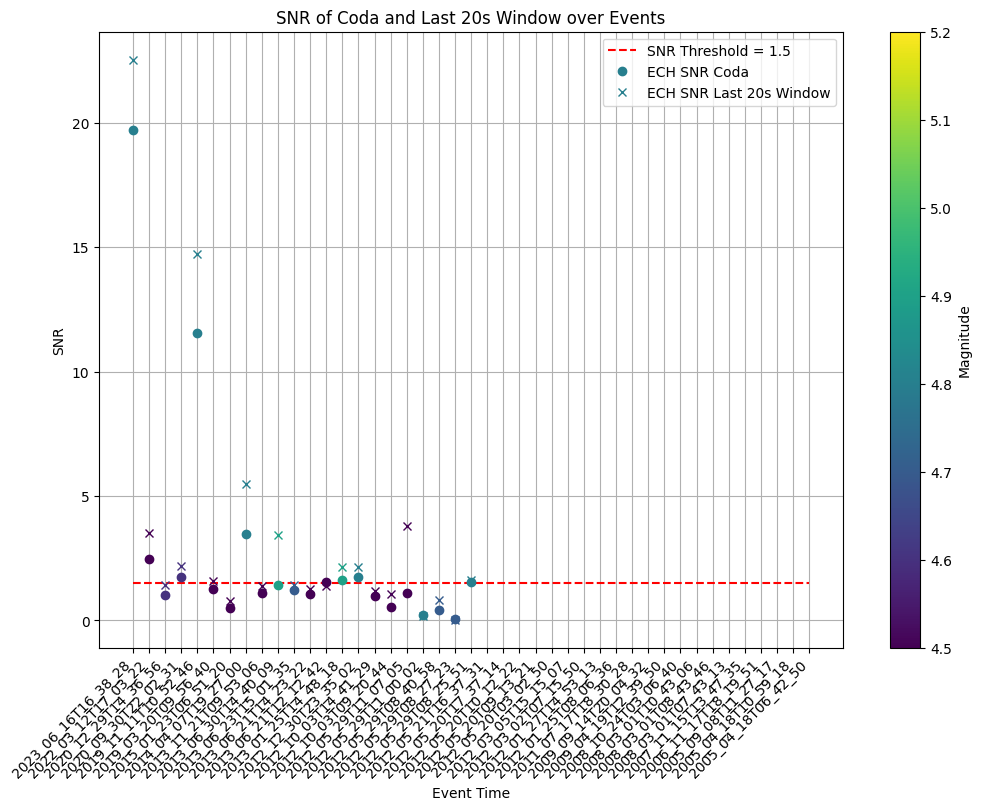

In [73]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

stations_to_plot = ["ECH"]
events = range(len(amplitudes_dict[station2]))

fig, ax = plt.subplots(figsize=(12, 8))

for station in stations_to_plot:
    snr_coda_values = np.array([entry['snr_coda'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    snr_last_window_values = np.array([entry['snr_last_window'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    magnitudes = np.array([entry['magnitude'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    times = np.array([entry['time'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=str)
    
    valid_indices = [i for i, time in enumerate(times) if time != 'None']
    valid_times = [times[i] for i in valid_indices]
    snr_coda_values = snr_coda_values[valid_indices]
    snr_last_window_values = snr_last_window_values[valid_indices]
    magnitudes = magnitudes[valid_indices]
    
    norm = mcolors.Normalize(vmin=np.nanmin(magnitudes), vmax=np.nanmax(magnitudes))
    cmap = cm.viridis

    ax.hlines(1.5, 0, len(valid_times) - 1, colors='r', linestyles='--', label='SNR Threshold = 1.5')
    label_coda = f'{station} SNR Coda'
    label_last = f'{station} SNR Last 20s Window'
    for i, (snr_coda, snr_last, mag) in enumerate(zip(snr_coda_values, snr_last_window_values, magnitudes)):
        if not np.isnan(snr_coda):
            ax.plot(i, snr_coda, 'o', color=cmap(norm(mag)), label=label_coda)
            label_coda = ""  # Clear the label after the first use
        if not np.isnan(snr_last):
            ax.plot(i, snr_last, 'x', color=cmap(norm(mag)), label=label_last)
            label_last = ""  # Clear the label after the first use

ax.set_xticks(range(len(valid_times)))
ax.set_xticklabels(valid_times, rotation=45, ha='right')
ax.set_xlabel("Event Time")
ax.set_ylabel("SNR")
ax.set_title("SNR of Coda and Last 20s Window over Events")
ax.legend()
ax.grid(True)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Magnitude')
plt.show()


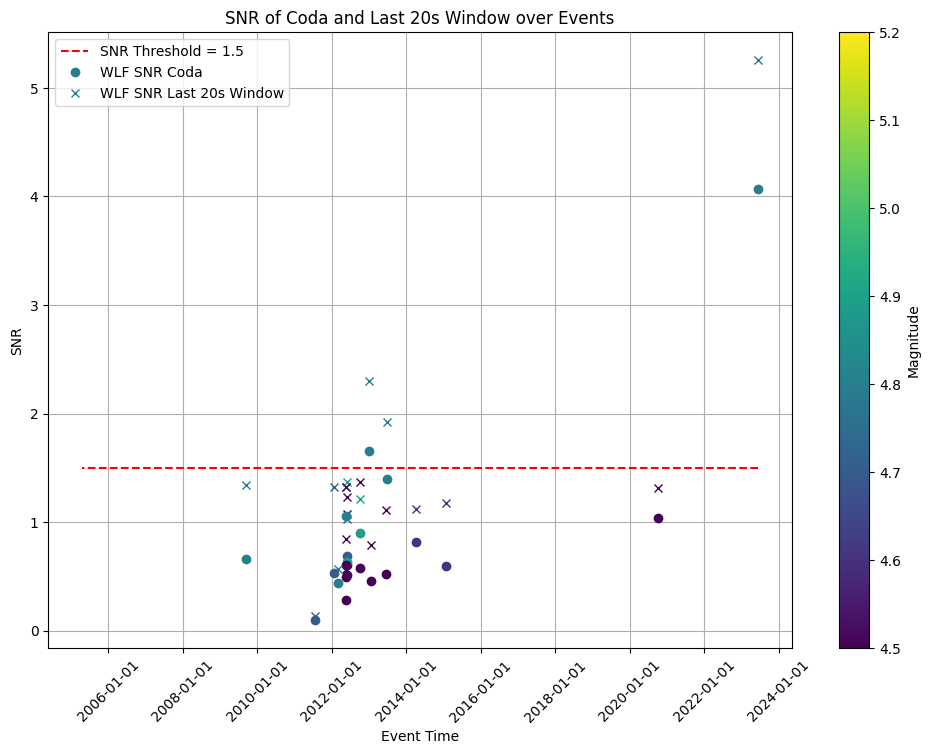

In [71]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

stations_to_plot = ["WLF"]
events = range(len(amplitudes_dict[station2]))

fig, ax = plt.subplots(figsize=(12, 8))

for station in stations_to_plot:
    snr_coda_values = np.array([entry['snr_coda'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    snr_last_window_values = np.array([entry['snr_last_window'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    magnitudes = np.array([entry['magnitude'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    times = np.array([entry['time'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=str)
    
    valid_times = [datetime.strptime(time, '%Y_%m_%dT%H_%M_%S') for time in times if time != 'None']
    snr_coda_values = np.where(snr_coda_values == None, np.nan, snr_coda_values)
    snr_last_window_values = np.where(snr_last_window_values == None, np.nan, snr_last_window_values)
    magnitudes = np.where(magnitudes == None, np.nan, magnitudes)
    #print(times)
    #print(snr_coda_values)
    norm = mcolors.Normalize(vmin=np.nanmin(magnitudes), vmax=np.nanmax(magnitudes))
    cmap = cm.viridis

    ax.hlines(1.5, valid_times[0], valid_times[-1], colors='r', linestyles='--', label='SNR Threshold = 1.5')
    label_coda = f'{station} SNR Coda'
    label_last = f'{station} SNR Last 20s Window'
    for i, (snr_coda, snr_last, mag, time) in enumerate(zip(snr_coda_values, snr_last_window_values, magnitudes, valid_times)):
        if not np.isnan(snr_coda):
            ax.plot(time, snr_coda, 'o', color=cmap(norm(mag)), label=label_coda)
            label_coda = ""  # Clear the label after the first use
        if not np.isnan(snr_last):
            ax.plot(time, snr_last, 'x', color=cmap(norm(mag)), label=label_last)
            label_last = ""  # Clear the label after the first use

ax.set_xlabel("Event Time")
ax.set_ylabel("SNR")
ax.set_title("SNR of Coda and Last 20s Window over Events")
ax.legend()
ax.grid(True)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Magnitude')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.show()


Using fallback station ECH for station CI18
Using fallback station ECH for station CI19
Using fallback station ECH for station CI20
Using fallback station ECH for station BETS
Using fallback station ECH for station ILLK
Using fallback station ECH for station OPS
Using fallback station ECH for station ADHE
Using fallback station ECH for station AGO
Using fallback station ECH for station AJAC
Using fallback station ECH for station ARBF
Using fallback station ECH for station ARTF
Using fallback station ECH for station ATE
Using fallback station ECH for station BALS
Using fallback station ECH for station BANN
Using fallback station ECH for station BARI
Using fallback station ECH for station BESN
Using fallback station ECH for station BETHI
Using fallback station ECH for station BIMF
Using fallback station ECH for station BLAF
Using fallback station ECH for station BORF
Using fallback station ECH for station BOUC
Using fallback station ECH for station BSTF
Using fallback station ECH for sta

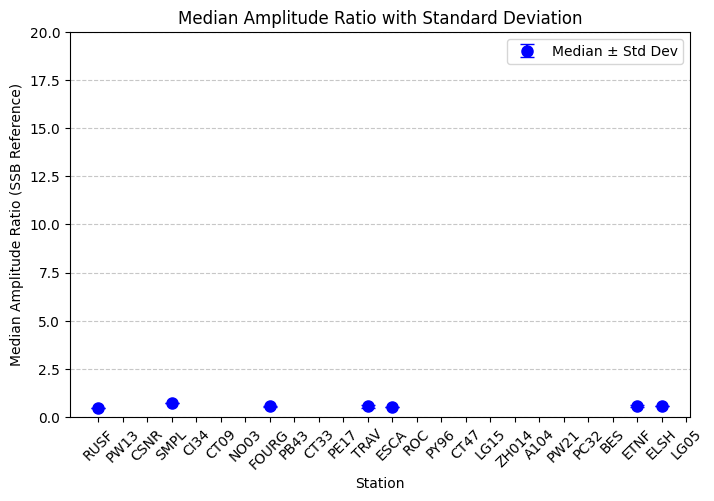

In [107]:
import random

station2 = "SSB"
fallback_stations = ["ECH", "MLS", "CHIF"]
amplitude_ratios = {}

total_stations = len(amplitudes_dict.keys())
stations_with_no_valid_ratio = 0

for station1 in amplitudes_dict.keys():
    denom_amplitudes = np.array([entry['amplitude'] if entry is not None and entry.get('snr_coda', 0) is not None and entry.get('snr_coda', 0) > 1.5 else None for entry in amplitudes_dict[station1]], dtype=np.float64)
    counter_amplitudes = np.array([entry['amplitude'] if entry is not None and entry.get('snr_coda', 0) is not None and entry.get('snr_coda', 0) > 1.5 else None for entry in amplitudes_dict[station2]], dtype=np.float64)

    denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
    counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

    if np.isnan(counter_amplitudes).all():
        for fallback_station in fallback_stations:
            counter_amplitudes = np.array([entry['amplitude'] if entry is not None and entry.get('snr_coda', 0) is not None and entry.get('snr_coda', 0) > 1.5 else None for entry in amplitudes_dict[fallback_station]], dtype=np.float64)
            counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)
            if not np.isnan(counter_amplitudes).all():
                print(f"Using fallback station {fallback_station} for station {station1}")
                break

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]
    
    if len(valid_ratios) > 0:
        amplitude_ratios[station1] = {
            "median": np.nanmedian(valid_ratios),
            "std": np.nanstd(valid_ratios),
        }
    else:
        amplitude_ratios[station1] = {
            "median": np.nan,
            "std": np.nan,
        }
        stations_with_no_valid_ratio += 1

print(f"Total number of stations: {total_stations}")
print(f"Number of stations with no valid ratio: {stations_with_no_valid_ratio}")

stations_list = list(amplitude_ratios.keys())
station_tests = random.sample(list(amplitudes_dict.keys()), 25)
median_values = [amplitude_ratios[st]["median"] for st in station_tests]
std_values = [amplitude_ratios[st]["std"] for st in station_tests]

plt.figure(figsize=(8, 5))
plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

plt.xlabel("Station")
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title(f"Median Amplitude Ratio with Standard Deviation")
plt.legend()
plt.ylim(0, 20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()



Using fallback station BALS for station CI18
Using fallback station BALS for station CI19
Using fallback station BALS for station CI20
Using fallback station BALS for station BETS
Using fallback station BALS for station ILLK
Using fallback station BALS for station OPS
Using fallback station BALS for station ADHE
Using fallback station BALS for station AGO
Using fallback station BALS for station AJAC
Using fallback station BALS for station ARBF
Using fallback station BALS for station ARTF
Using fallback station BALS for station ATE
Using fallback station BALS for station BALS
Using fallback station BALS for station BANN
Using fallback station BALS for station BARI
Using fallback station BALS for station BESN
Using fallback station BALS for station BETHI
Using fallback station BALS for station BIMF
Using fallback station BALS for station BLAF
Using fallback station BALS for station BORF
Using fallback station BALS for station BOUC
Using fallback station BALS for station BSTF
Using fallba

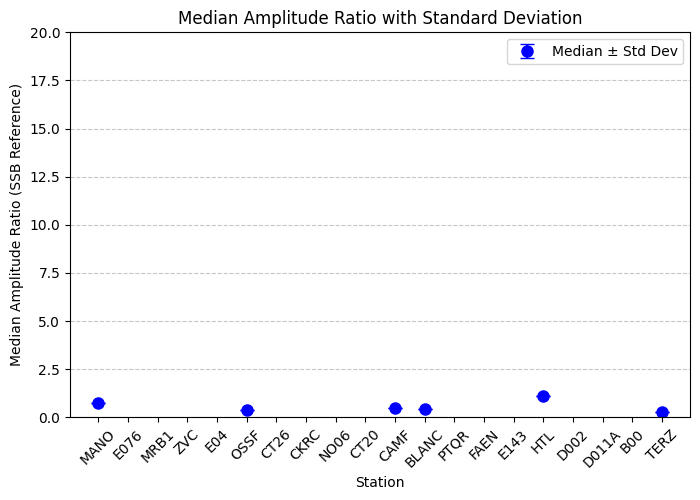

In [112]:
import numpy as np
import random
import matplotlib.pyplot as plt

station2 = "SSB"
fallback_stations = ["BALS","ECH", "MLS", "CHIF"]
amplitude_ratios = {}

total_stations = len(amplitudes_dict.keys())
stations_with_no_valid_ratio = 0

for station1 in amplitudes_dict.keys():
    denom_amplitudes = np.array([
        entry['amplitude'] if entry is not None and entry.get('snr_coda') is not None and entry['snr_coda'] > 1.5 else np.nan
        for entry in amplitudes_dict[station1]
    ])
    
    counter_amplitudes = np.array([
        entry['amplitude'] if entry is not None and entry.get('snr_coda') is not None and entry['snr_coda'] > 1.5 else np.nan
        for entry in amplitudes_dict.get(station2, [])
    ])

    # If the reference station has no valid amplitudes, check fallback stations
    if np.isnan(counter_amplitudes).all():
        found_fallback = False  # Flag to check if we find a valid fallback
        for fallback_station in fallback_stations:
            fallback_amplitudes = np.array([
                entry['amplitude'] if entry is not None and entry.get('snr_coda') is not None and entry['snr_coda'] > 1.5 else np.nan
                for entry in amplitudes_dict.get(fallback_station, [])
            ])
            if not np.isnan(fallback_amplitudes).all():  # If fallback station has valid data
                counter_amplitudes = fallback_amplitudes  # Use fallback station
                print(f"Using fallback station {fallback_station} for station {station1}")
                found_fallback = True
                break  # Stop after finding the first valid fallback

        if not found_fallback:
            print(f"No valid fallback station found for {station1}")

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]

    if len(valid_ratios) > 0:
        amplitude_ratios[station1] = {
            "median": np.nanmedian(valid_ratios),
            "std": np.nanstd(valid_ratios),
        }
    else:
        amplitude_ratios[station1] = {
            "median": np.nan,
            "std": np.nan,
        }
        stations_with_no_valid_ratio += 1


print(f"Total number of stations: {total_stations}")
print(f"Number of stations with no valid ratio: {stations_with_no_valid_ratio}")

stations_list = list(amplitude_ratios.keys())
station_tests = random.choices(list(amplitudes_dict.keys()), k=min(25, len(amplitudes_dict)))

median_values = [amplitude_ratios[st]["median"] for st in station_tests]
std_values = [amplitude_ratios[st]["std"] for st in station_tests]

plt.figure(figsize=(8, 5))
plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

plt.xlabel("Station")
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title("Median Amplitude Ratio with Standard Deviation")
plt.legend()
plt.ylim(0, 20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()


In [ ]:
station2 = "SSB"
amplitude_ratios = {}

for station1 in amplitudes_dict.keys():
    denom_amplitudes = np.array(amplitudes_dict[station1], dtype=np.float64)
    counter_amplitudes = np.array(amplitudes_dict[station2], dtype=np.float64)

    denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
    counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]
    
    if len(valid_ratios) > 0:
        amplitude_ratios[station1] = {
            "median": np.nanmedian(valid_ratios),
            "std": np.nanstd(valid_ratios),
        }
    else:
        amplitude_ratios[station1] = {
            "median": np.nan,
            "std": np.nan,
        }

stations_list = list(amplitude_ratios.keys())
station_tests = random.sample(list(amplitudes_dict.keys()), 25)
median_values = [amplitude_ratios[st]["median"] for st in station_tests]
std_values = [amplitude_ratios[st]["std"] for st in station_tests]

plt.figure(figsize=(8, 5))
plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

plt.xlabel("Station")
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title(f"Median Amplitude Ratio with Standard Deviation")
plt.legend()
plt.ylim(0, 20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()


TypeError: list indices must be integers or slices, not str

25


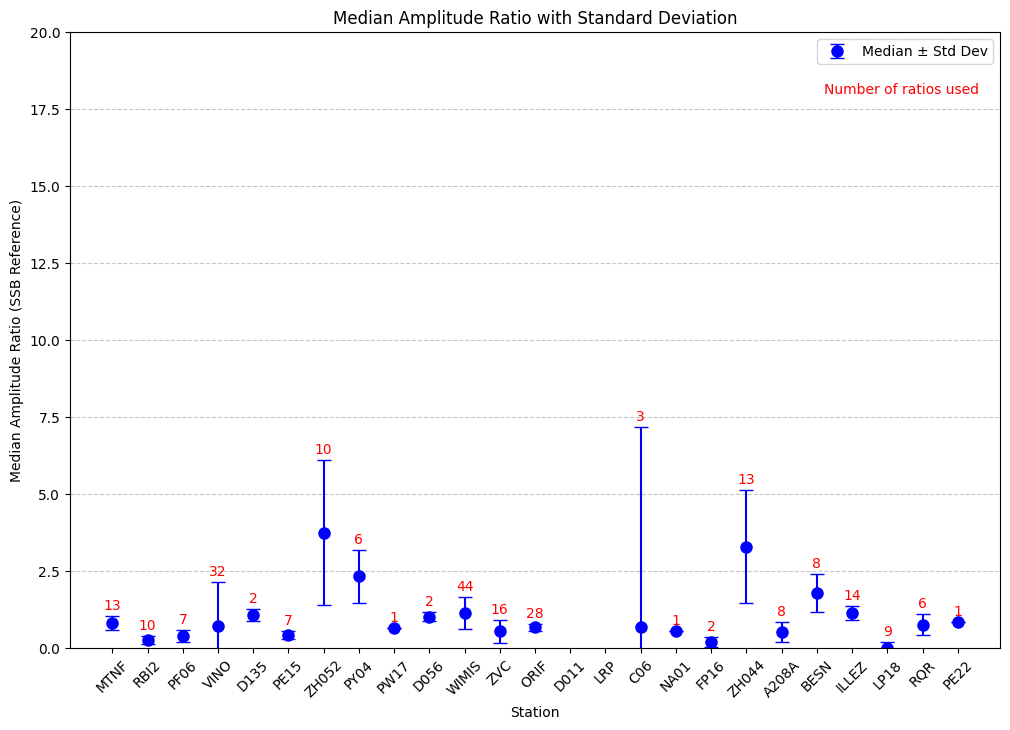

In [18]:
station_tests = random.sample(list(amplitudes_dict.keys()), 25)
print(len(station_tests))
plt.figure(figsize=(12, 8))

for i, station in enumerate(station_tests):
    median = amplitude_ratios[station]["median"]
    std = amplitude_ratios[station]["std"]
    
    denom_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    counter_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

    denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
    counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]
    
    count = len(valid_ratios)
    
    plt.errorbar(station, median, yerr=std, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev" if i == 0 else "")
    plt.text(i, median + std + 0.2, f"{count}", ha="center", fontsize=10, color="red")

plt.xticks(rotation=45)
plt.xlabel("Station")
plt.ylim(0, 20)
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title(f"Median Amplitude Ratio with Standard Deviation")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.text(24.6, 18, "Number of ratios used", color="red", ha="right", fontsize=10)
plt.show()


Total number of stations: 1770
Number of stations with no valid ratio: 93


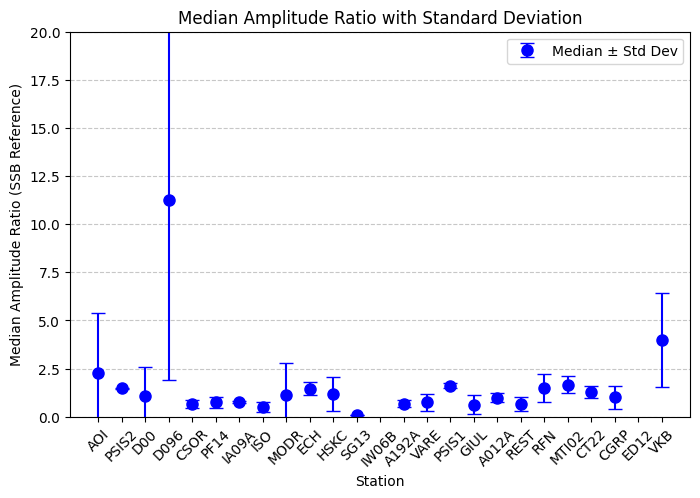

In [58]:
def site_effect(eq_file='/home/schreinl/Stage/Data/eq_4_france.csv', codafile='envelope_amps_fac_1.5_dict',sample_size=25,ref_station1 = "SSB", ref_station2 = "ECH", ratio_plot = False):
    '''
    Function calculates the site effect for each station by building the median amplitude ratio of each station to the reference station.
    For each event and for each station the site effect is calculated.
    output should be one large
    Inputs: earthquakes in a list, codafile which is the ending of the files that contain the amplitudes
    Output: a dictionary with the site effect for each station

    '''

    #read in the earthquake list
    eq_list = pd.read_csv(eq_file)

    #create the dictionary
    amplitudes_dict = {}

    #fill the dict with the amplitudes, so for a specific coda window file the amplitudes are read in
    for i in range(len(eq_list)):
        start = UTCDateTime(eq_list["time"][i])
        time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
        
        try:    #/home/schreinl/Stage/Data/{time_string}/{time_string}_envelope_amps_fac_1.5_dict.txt
            with open(f"/home/schreinl/Stage/Data/{time_string}/{time_string}_{codafile}.txt", "r") as file:
                amp_dict = json.load(file)

            for station, data in amp_dict.items():
                if station not in amplitudes_dict:
                    amplitudes_dict[station] = [None] * i 
                amplitudes_dict[station].append(data["amplitude"])
            
            for station in amplitudes_dict:
                if station not in amp_dict:
                    amplitudes_dict[station].append(None)
        except FileNotFoundError:
            for station in amplitudes_dict:
                amplitudes_dict[station].append(None)

        #so now we have a dictionary with the amplitudes for each station for each event, so dimensions are N number of events given,
        # and M number of stations that have recorded at least one event

    # if we wanted to test what we did, we use a smaller batch size of stations
    sample_size = min(sample_size, len(amplitudes_dict.keys()))
    station_tests = random.sample(list(amplitudes_dict.keys()), sample_size)

    #here we choose the reference stations
    station2 = ref_station1
    fallback_station = ref_station2
    amplitude_ratios = {}

    # Counters for stations with and without valid ratios
    total_stations = len(amplitudes_dict.keys())
    stations_with_no_valid_ratio = 0

    for station1 in amplitudes_dict.keys():
        denom_amplitudes = np.array(amplitudes_dict[station1], dtype=np.float64)
        counter_amplitudes = np.array(amplitudes_dict[station2], dtype=np.float64)

        # Replace None with np.nan
        denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
        counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

        # Check if the reference station has missing values and use fallback if necessary
        
        # Check if the reference station has missing values and use fallback if necessary
        if np.isnan(counter_amplitudes).all():
            print(f"Using fallback station {fallback_station} for station {station1}")
            counter_amplitudes = np.array(amplitudes_dict[fallback_station], dtype=np.float64)
            counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

        # Calculate the ratio
        ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
        valid_ratios = ratio[~np.isnan(ratio)]
        
        if len(valid_ratios) > 0:
            amplitude_ratios[station1] = {
                "median": np.nanmedian(valid_ratios),
                "std": np.nanstd(valid_ratios),
            }
        else:
            amplitude_ratios[station1] = {
                "median": np.nan,
                "std": np.nan,
            }
            #print(f"No valid ratio computed for station {station1}")
            stations_with_no_valid_ratio += 1

    # Print the number of stations with no valid ratio and the total number of stations
    print(f"Total number of stations: {total_stations}")
    print(f"Number of stations with no valid ratio: {stations_with_no_valid_ratio}")

    if ratio_plot == True:
        station_tests = random.sample(list(amplitudes_dict.keys()), 25)
        median_values = [amplitude_ratios[st]["median"] for st in station_tests]
        std_values = [amplitude_ratios[st]["std"] for st in station_tests]

        plt.figure(figsize=(8, 5))
        plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

        plt.xlabel("Station")
        plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
        plt.title(f"Median Amplitude Ratio with Standard Deviation")
        plt.legend()
        plt.ylim(0, 20)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.xticks(rotation=45)
        plt.show()

    return amplitude_ratios
        
    
amplitude_ratio = site_effect(eq_file='/home/schreinl/Stage/Data/eq_4_france.csv', codafile='envelope_amps_fac_1.5_dict',sample_size=25,ref_station1 = "SSB", ref_station2 = "ECH", ratio_plot = True)